In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn streamlit


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())
print("\nChurn distribution:")
print(df['Churn'].value_counts())


FileNotFoundError: [Errno 2] No such file or directory: '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [6]:
import os
print(os.getcwd())

C:\Users\USER\OneDrive\Desktop\customer-churn-project


In [4]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn info:")
print(df.info())
print("\nChurn distribution:")
print(df['Churn'].value_counts())

Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

In [7]:
print("All columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nAny null values?")
print(df.isnull().sum())

All columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Any null values?
customerID          0
gender  

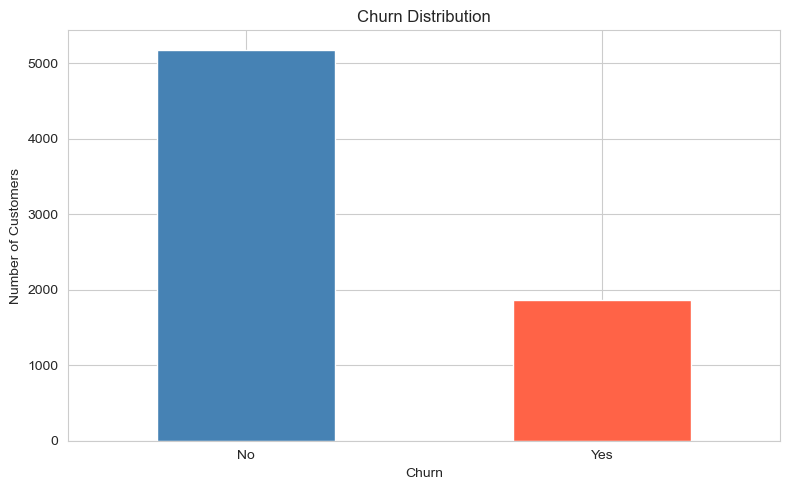

No = 5174 | Yes = 1869


In [8]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# 1. Churn Distribution
plt.figure()
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("No =", df['Churn'].value_counts()['No'], "| Yes =", df['Churn'].value_counts()['Yes'])

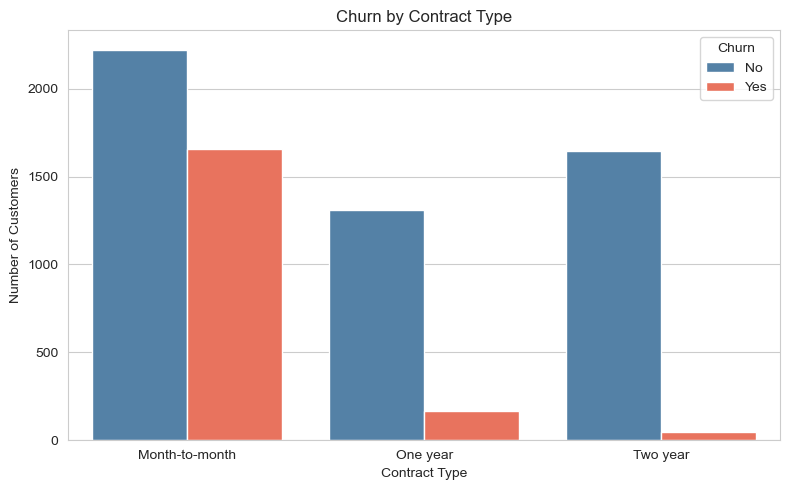

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64


In [9]:
# 2. Churn vs Contract Type
plt.figure()
sns.countplot(data=df, x='Contract', hue='Churn', 
              palette={'No': 'steelblue', 'Yes': 'tomato'})
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

# Print numbers
print(df.groupby('Contract')['Churn'].value_counts())

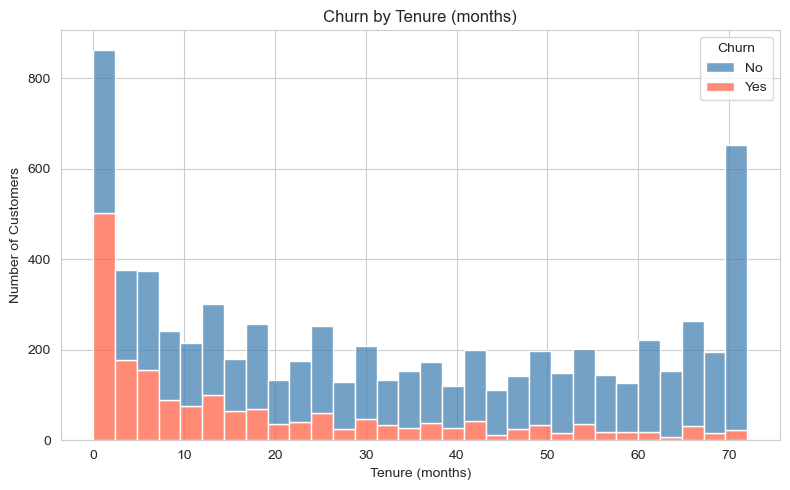

Average tenure - Churned customers: 18.0 months
Average tenure - Retained customers: 37.6 months


In [10]:
# 3. Churn vs Tenure
plt.figure()
sns.histplot(data=df, x='tenure', hue='Churn',
             palette={'No': 'steelblue', 'Yes': 'tomato'},
             bins=30, multiple='stack')
plt.title('Churn by Tenure (months)')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Average tenure - Churned customers:", 
      round(df[df['Churn']=='Yes']['tenure'].mean(), 1), "months")
print("Average tenure - Retained customers:", 
      round(df[df['Churn']=='No']['tenure'].mean(), 1), "months")

C:\Users\USER\AppData\Local\Temp\ipykernel_5516\1273141618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',


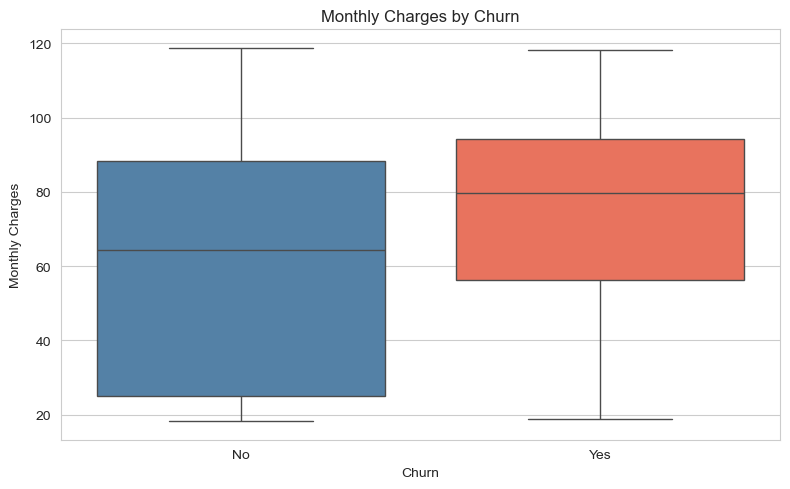

Average monthly charges - Churned: 74.44
Average monthly charges - Retained: 61.27


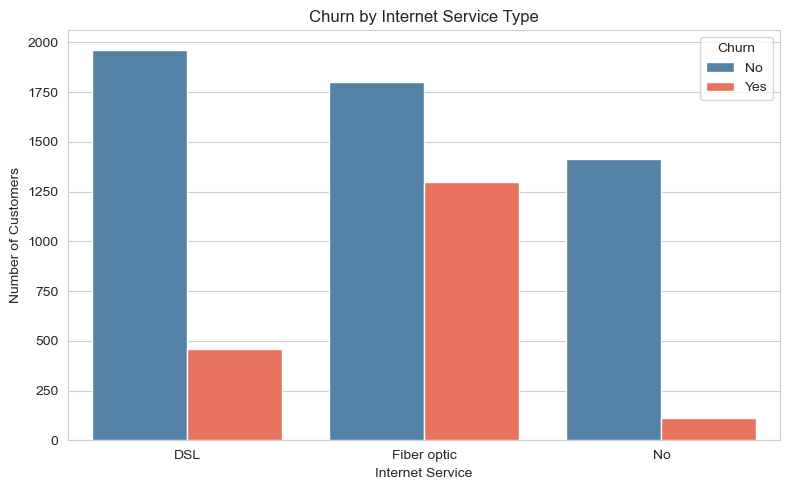

In [11]:
# 4. Churn vs Monthly Charges
plt.figure()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'No': 'steelblue', 'Yes': 'tomato'})
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

print("Average monthly charges - Churned:", 
      round(df[df['Churn']=='Yes']['MonthlyCharges'].mean(), 2))
print("Average monthly charges - Retained:", 
      round(df[df['Churn']=='No']['MonthlyCharges'].mean(), 2))

# 5. Churn vs Internet Service
plt.figure()
sns.countplot(data=df, x='InternetService', hue='Churn',
              palette={'No': 'steelblue', 'Yes': 'tomato'})
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

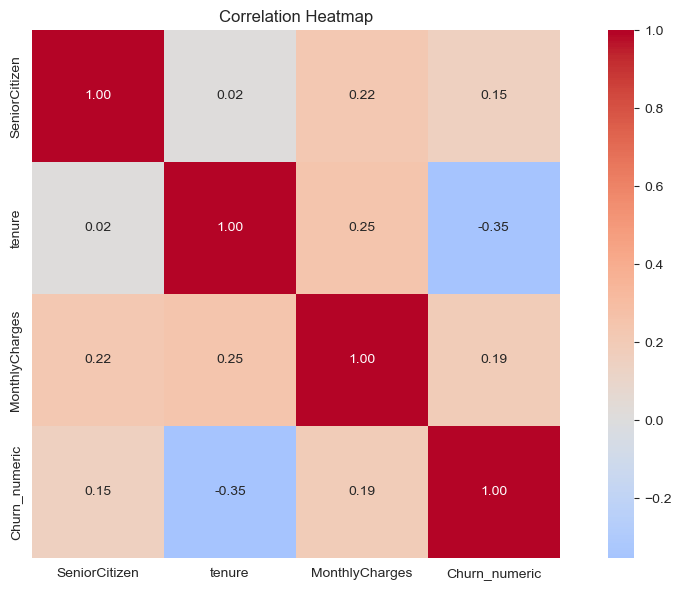

In [12]:
# 6. Correlation Heatmap
plt.figure(figsize=(10, 6))

# Convert churn to numeric for correlation
df_corr = df.copy()
df_corr['Churn_numeric'] = (df_corr['Churn'] == 'Yes').astype(int)

# Only numeric columns
numeric_cols = df_corr.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df_corr[numeric_cols].corr(), 
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [13]:
# Check TotalCharges issue
print(df['TotalCharges'].unique()[:20])
print("\nHow many spaces in TotalCharges?")
print(df[df['TotalCharges'] == ' '].shape[0])

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']

How many spaces in TotalCharges?
11


In [14]:
# Fix TotalCharges - replace spaces with NaN then convert to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', float('nan'))
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Fill the 11 missing values with 0 (new customers, not yet charged)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify fix
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("Any nulls left?", df['TotalCharges'].isnull().sum())
print("\nSample values:", df['TotalCharges'].head())

TotalCharges dtype: float64
Any nulls left? 0

Sample values: 0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64


In [15]:
# Step 2 - Drop customerID (not useful for prediction)
df = df.drop('customerID', axis=1)
print("Columns after dropping customerID:", df.shape)

# Step 3 - Convert SeniorCitizen from 0/1 to Yes/No 
# (to be consistent with other columns)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Step 4 - Convert target column Churn to 0/1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Check
print("\nChurn column after encoding:")
print(df['Churn'].value_counts())
print("\nSeniorCitizen sample:")
print(df['SeniorCitizen'].value_counts())

Columns after dropping customerID: (7043, 20)

Churn column after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64

SeniorCitizen sample:
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [16]:
# Step 5 - Encode all categorical columns using Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Find all categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# Encode each one
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Verify
print("\nData types after encoding:")
print(df.dtypes)
print("\nSample of encoded data:")
print(df.head(3))

Categorical columns to encode: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Data types after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Sample of encoded data:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0     

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 6 - Separate features and target
X = df.drop('Churn', axis=1)  # All columns except Churn
y = df['Churn']                # Only Churn column

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Step 7 - Scale numerical columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 8 - Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\n Data is ready for modelling!")

Features shape: (7043, 19)
Target shape: (7043,)

Training set size: (5634, 19)
Testing set size: (1409, 19)

 Data is ready for modelling!


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report

# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("=== Logistic Regression Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression Results ===
Accuracy: 81.55 %

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [19]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("=== Random Forest Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Compare both models
print("=== Model Comparison ===")
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_lr) * 100, 2), "%")
print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")

=== Random Forest Results ===
Accuracy: 79.56 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409

=== Model Comparison ===
Logistic Regression Accuracy: 81.55 %
Random Forest Accuracy: 79.56 %


C:\Users\USER\AppData\Local\Temp\ipykernel_5516\3551147246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices],


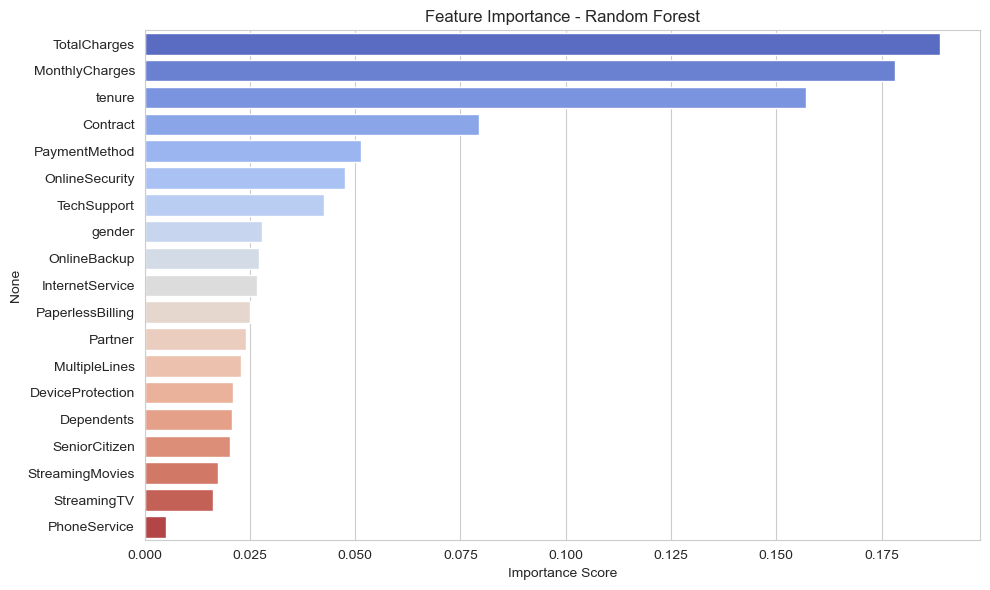

Top 5 most important features:
1. TotalCharges — 18.89%
2. MonthlyCharges — 17.81%
3. tenure — 15.71%
4. Contract — 7.95%
5. PaymentMethod — 5.13%


In [20]:
# Feature Importance
feature_names = df.drop('Churn', axis=1).columns
importances = rf_model.feature_importances_
indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices],
            y=feature_names[indices],
            palette='coolwarm')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Print top 5
print("Top 5 most important features:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]} — {round(importances[indices[i]]*100, 2)}%")

In [21]:
import joblib

# Save model and scaler
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(df.drop('Churn', axis=1).columns.tolist(), 'feature_names.pkl')

print("Model saved successfully!")
print("Files saved in:", os.getcwd())

Model saved successfully!
Files saved in: C:\Users\USER\OneDrive\Desktop\customer-churn-project
